In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
RANDOM_STATE = 42

In [35]:
df = pd.read_csv("data.csv")

print("Розмір датасету:", df.shape)
display(df.head())

Розмір датасету: (2043, 9)


,process.b1.capacity,process.b2.capacity,process.b3.capacity,process.b4.capacity,property.price,property.product,property.winner,verification.result,verification.time
0,0,0,2,1,59,1,0,False,163.316667
1,0,0,2,1,59,2,0,False,200.860000
2,0,0,2,1,59,4,0,False,154.888889
3,0,0,2,1,59,6,0,False,108.640000
4,0,0,2,1,60,1,0,True,85.466667


In [36]:
print("Інформація про датасет:")
df.info()
print("Кількість пропусків у кожній колонці:")
display(df.isna().sum())
print("Типи даних:")
display(df.dtypes)
categorical_columns = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("Категоріальні колонки:", categorical_columns if categorical_columns else "Категоріальних колонок немає")

Інформація про датасет:
<class 'pandas.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   process.b1.capacity  2043 non-null   int64  
 1   process.b2.capacity  2043 non-null   int64  
 2   process.b3.capacity  2043 non-null   int64  
 3   process.b4.capacity  2043 non-null   int64  
 4   property.price       2043 non-null   int64  
 5   property.product     2043 non-null   int64  
 6   property.winner      2043 non-null   int64  
 7   verification.result  2043 non-null   bool   
 8   verification.time    2043 non-null   float64
dtypes: bool(1), float64(1), int64(7)
memory usage: 129.8 KB
Кількість пропусків у кожній колонці:


process.b1.capacity    0
process.b2.capacity    0
process.b3.capacity    0
process.b4.capacity    0
property.price         0
property.product       0
property.winner        0
verification.result    0
verification.time      0
dtype: int64

Типи даних:


process.b1.capacity      int64
process.b2.capacity      int64
process.b3.capacity      int64
process.b4.capacity      int64
property.price           int64
property.product         int64
property.winner          int64
verification.result       bool
verification.time      float64
dtype: object

Категоріальні колонки: ['verification.result']


In [37]:
target_column = "verification.result"
time_column = "verification.time"
print("Розподіл класів:")
print(df[target_column].value_counts())
print("Розподіл класів у відсотках:")
print((df[target_column].value_counts(normalize=True) * 100).round(2))

Розподіл класів:
verification.result
False    1781
True      262
Name: count, dtype: int64
Розподіл класів у відсотках:
verification.result
False    87.18
True     12.82
Name: proportion, dtype: float64


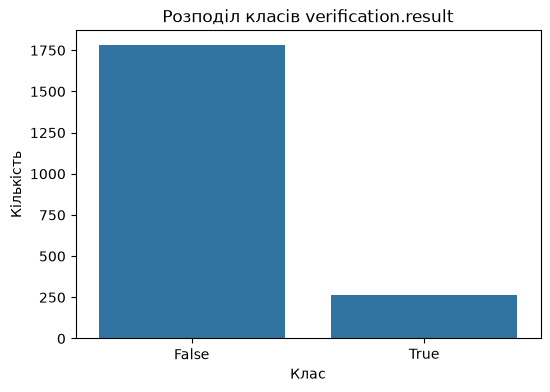

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(x=target_column, data=df)
plt.title("Розподіл класів verification.result")
plt.xlabel("Клас")
plt.ylabel("Кількість")
plt.show()

In [39]:
print("Опис числових фіч:")
display(df.describe())

Опис числових фіч:


,process.b1.capacity,process.b2.capacity,process.b3.capacity,process.b4.capacity,property.price,property.product,property.winner,verification.time
count,2043.000000,2043.000000,2043.000000,2043.000000,2043.000000,2043.000000,2043.000000,2043.000000
mean,1.000000,2.093979,1.883994,0.587861,71.473324,3.252080,0.455213,7336.944574
std,0.816696,0.811269,0.320310,0.492340,8.048740,1.804225,1.062828,10375.393650
min,0.000000,0.000000,1.000000,0.000000,59.000000,1.000000,0.000000,77.916667
25%,0.000000,1.000000,2.000000,0.000000,65.000000,2.000000,0.000000,546.818910
50%,1.000000,2.000000,2.000000,1.000000,70.000000,3.000000,0.000000,1316.983333
75%,2.000000,3.000000,2.000000,1.000000,78.000000,5.000000,0.000000,10876.638889
max,2.000000,3.000000,2.000000,1.000000,90.000000,6.000000,4.000000,44130.520833


In [40]:
X = df.drop(columns=[target_column, time_column])
y = df[target_column]
print("Розмір X:", X.shape)
print("Розмір y:", y.shape)
display(X.head())

Розмір X: (2043, 7)
Розмір y: (2043,)


,process.b1.capacity,process.b2.capacity,process.b3.capacity,process.b4.capacity,property.price,property.product,property.winner
0,0,0,2,1,59,1,0
1,0,0,2,1,59,2,0
2,0,0,2,1,59,4,0
3,0,0,2,1,59,6,0
4,0,0,2,1,60,1,0


In [41]:
X_fe = X.copy()

capacity_columns = [col for col in X_fe.columns if "capacity" in col]
X_fe["capacity_total"] = X_fe[capacity_columns].sum(axis=1)
X_fe["price_per_capacity"] = X_fe["property.price"] / (X_fe["capacity_total"] + 1)

if "property.product" in X_fe.columns and "property.winner" in X_fe.columns:
    X_fe["product_winner_match"] = (X_fe["property.product"] == X_fe["property.winner"]).astype(int)
print("Новий розмір X після feature engineering:", X_fe.shape)
display(X_fe.head())

Новий розмір X після feature engineering: (2043, 10)


,process.b1.capacity,process.b2.capacity,process.b3.capacity,process.b4.capacity,property.price,property.product,property.winner,capacity_total,price_per_capacity,product_winner_match
0,0,0,2,1,59,1,0,3,14.75,0
1,0,0,2,1,59,2,0,3,14.75,0
2,0,0,2,1,59,4,0,3,14.75,0
3,0,0,2,1,59,6,0,3,14.75,0
4,0,0,2,1,60,1,0,3,15.00,0


In [42]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_fe,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1225, 10) (1225,)
Validation: (409, 10) (409,)
Test: (409, 10) (409,)


In [43]:
numeric_features = X_fe.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="passthrough"
)

print("Кількість числових фіч:", len(numeric_features))

Кількість числових фіч: 10


In [44]:
results = []

def evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append({
        "model": model_name,
        "train_accuracy": train_acc,
        "validation_accuracy": val_acc,
        "test_accuracy": test_acc
    })

    print(f"===== {model_name} =====")
    print("Train accuracy:", round(train_acc, 4))
    print("Validation accuracy:", round(val_acc, 4))
    print("Test accuracy:", round(test_acc, 4))
    print("\nClassification report on test:")
    print(classification_report(y_test, test_pred))

    cm = confusion_matrix(y_test, test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

===== Base Decision Tree =====
Train accuracy: 1.0
Validation accuracy: 0.978
Test accuracy: 0.9853

Classification report on test:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99       357
        True       0.98      0.90      0.94        52

    accuracy                           0.99       409
   macro avg       0.98      0.95      0.97       409
weighted avg       0.99      0.99      0.99       409



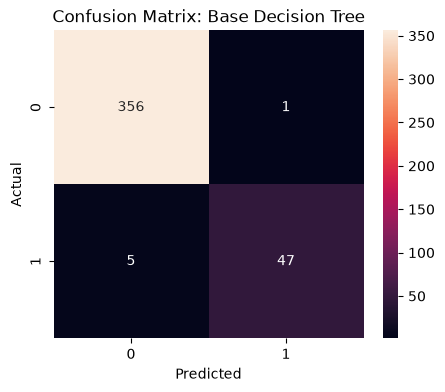

In [45]:
base_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

base_model.fit(X_train, y_train)
evaluate_model(base_model, "Base Decision Tree", X_train, y_train, X_val, y_val, X_test, y_test)

===== Bagging Default =====
Train accuracy: 0.9992
Validation accuracy: 0.9633
Test accuracy: 0.9756

Classification report on test:
              precision    recall  f1-score   support

       False       0.99      0.98      0.99       357
        True       0.89      0.92      0.91        52

    accuracy                           0.98       409
   macro avg       0.94      0.95      0.95       409
weighted avg       0.98      0.98      0.98       409



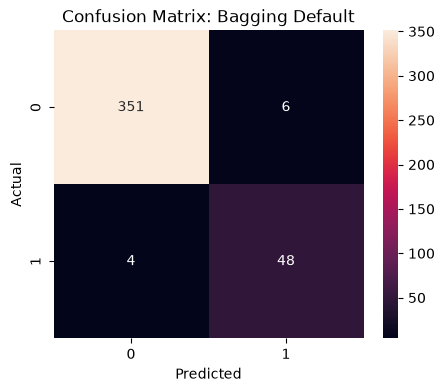

In [46]:
bagging_default = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", BaggingClassifier(random_state=RANDOM_STATE))
])

bagging_default.fit(X_train, y_train)
evaluate_model(bagging_default, "Bagging Default", X_train, y_train, X_val, y_val, X_test, y_test)

Найкращі параметри Bagging:
{'classifier__max_features': 1.0, 'classifier__max_samples': 1.0, 'classifier__n_estimators': 50}
===== Bagging Tuned =====
Train accuracy: 1.0
Validation accuracy: 0.978
Test accuracy: 0.9853

Classification report on test:
              precision    recall  f1-score   support

       False       0.99      0.99      0.99       357
        True       0.96      0.92      0.94        52

    accuracy                           0.99       409
   macro avg       0.97      0.96      0.97       409
weighted avg       0.99      0.99      0.99       409



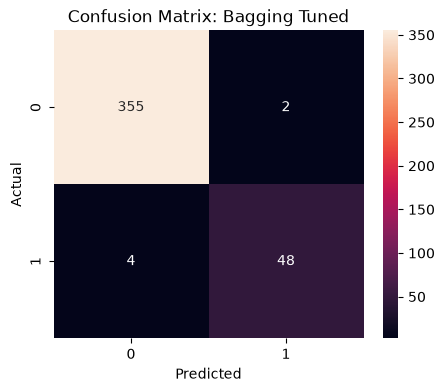

In [47]:
bagging_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", BaggingClassifier(random_state=RANDOM_STATE))
])

bagging_params = {
    "classifier__n_estimators": [10, 50, 100],
    "classifier__max_samples": [0.6, 0.8, 1.0],
    "classifier__max_features": [0.6, 0.8, 1.0]
}

bagging_grid = GridSearchCV(
    bagging_pipeline,
    bagging_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

bagging_grid.fit(X_train, y_train)
print("Найкращі параметри Bagging:")
print(bagging_grid.best_params_)
best_bagging = bagging_grid.best_estimator_
evaluate_model(best_bagging, "Bagging Tuned", X_train, y_train, X_val, y_val, X_test, y_test)

===== AdaBoost Default =====
Train accuracy: 0.9273
Validation accuracy: 0.9389
Test accuracy: 0.9242

Classification report on test:
              precision    recall  f1-score   support

       False       0.93      0.99      0.96       357
        True       0.86      0.48      0.62        52

    accuracy                           0.92       409
   macro avg       0.90      0.73      0.79       409
weighted avg       0.92      0.92      0.91       409



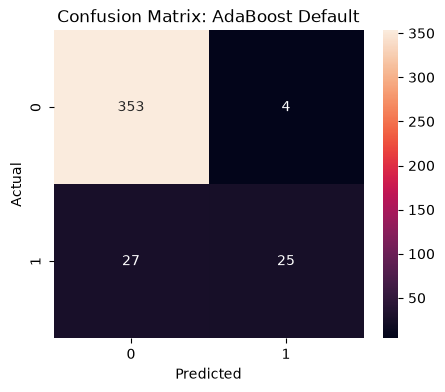

In [48]:
boosting_default = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", AdaBoostClassifier(random_state=RANDOM_STATE))
])

boosting_default.fit(X_train, y_train)
evaluate_model(boosting_default, "AdaBoost Default", X_train, y_train, X_val, y_val, X_test, y_test)

Найкращі параметри AdaBoost:
{'classifier__learning_rate': 1.0, 'classifier__n_estimators': 150}
===== AdaBoost Tuned =====
Train accuracy: 0.9461
Validation accuracy: 0.9487
Test accuracy: 0.9413

Classification report on test:
              precision    recall  f1-score   support

       False       0.95      0.98      0.97       357
        True       0.85      0.65      0.74        52

    accuracy                           0.94       409
   macro avg       0.90      0.82      0.85       409
weighted avg       0.94      0.94      0.94       409



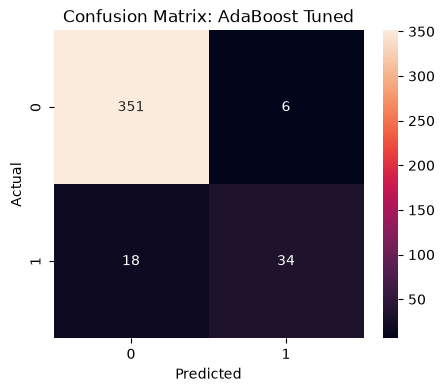

In [49]:
boosting_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", AdaBoostClassifier(random_state=RANDOM_STATE))
])

boosting_params = {
    "classifier__n_estimators": [50, 100, 150],
    "classifier__learning_rate": [0.01, 0.1, 1.0]
}

boosting_grid = GridSearchCV(
    boosting_pipeline,
    boosting_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

boosting_grid.fit(X_train, y_train)
print("Найкращі параметри AdaBoost:")
print(boosting_grid.best_params_)
best_boosting = boosting_grid.best_estimator_
evaluate_model(best_boosting, "AdaBoost Tuned", X_train, y_train, X_val, y_val, X_test, y_test)

===== Stacking Default =====
Train accuracy: 1.0
Validation accuracy: 0.978
Test accuracy: 0.9853

Classification report on test:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99       357
        True       0.98      0.90      0.94        52

    accuracy                           0.99       409
   macro avg       0.98      0.95      0.97       409
weighted avg       0.99      0.99      0.99       409



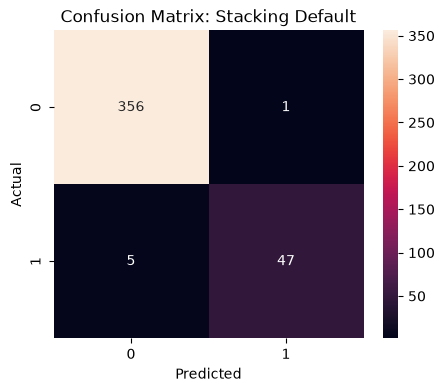

In [50]:
estimators = [
    ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ("knn", KNeighborsClassifier()),
    ("svc", SVC(probability=True, random_state=RANDOM_STATE))
]

stacking_default = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000),
        cv=3
    ))
])

stacking_default.fit(X_train, y_train)
evaluate_model(stacking_default, "Stacking Default", X_train, y_train, X_val, y_val, X_test, y_test)

Найкращі параметри Stacking:
{'classifier__final_estimator__C': 0.1, 'classifier__passthrough': False}
===== Stacking Tuned =====
Train accuracy: 1.0
Validation accuracy: 0.978
Test accuracy: 0.9853

Classification report on test:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99       357
        True       0.98      0.90      0.94        52

    accuracy                           0.99       409
   macro avg       0.98      0.95      0.97       409
weighted avg       0.99      0.99      0.99       409



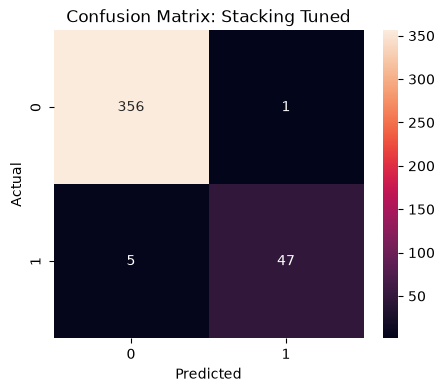

In [51]:
stacking_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000),
        cv=3
    ))
])

stacking_params = {
    "classifier__passthrough": [False, True],
    "classifier__final_estimator__C": [0.1, 1.0, 10.0]
}

stacking_grid = GridSearchCV(
    stacking_pipeline,
    stacking_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

stacking_grid.fit(X_train, y_train)
print("Найкращі параметри Stacking:")
print(stacking_grid.best_params_)
best_stacking = stacking_grid.best_estimator_
evaluate_model(best_stacking, "Stacking Tuned", X_train, y_train, X_val, y_val, X_test, y_test)

In [52]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="test_accuracy", ascending=False)
display(results_df)

,model,train_accuracy,validation_accuracy,test_accuracy
0,Base Decision Tree,1.000000,0.977995,0.985330
2,Bagging Tuned,1.000000,0.977995,0.985330
5,Stacking Default,1.000000,0.977995,0.985330
6,Stacking Tuned,1.000000,0.977995,0.985330
1,Bagging Default,0.999184,0.963325,0.975550
4,AdaBoost Tuned,0.946122,0.948655,0.941320
3,AdaBoost Default,0.927347,0.938875,0.924205


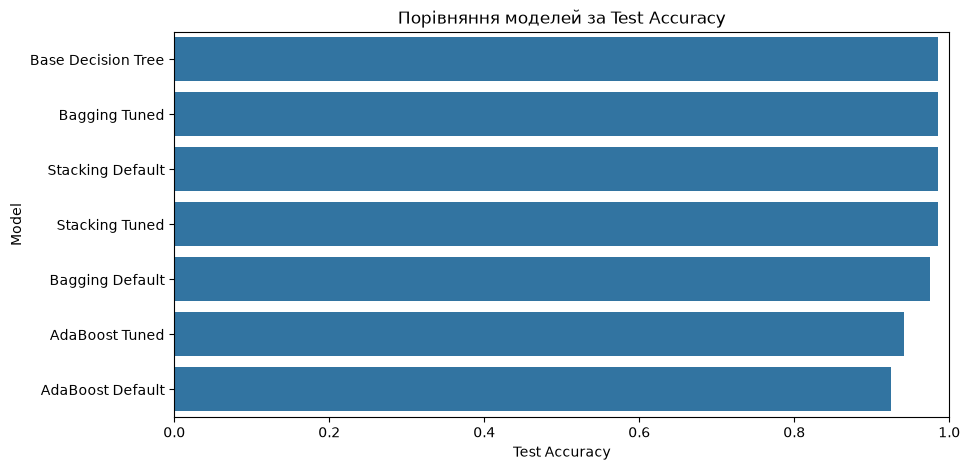

In [53]:
plt.figure(figsize=(10, 5))
sns.barplot(x="test_accuracy", y="model", data=results_df)
plt.title("Порівняння моделей за Test Accuracy")
plt.xlabel("Test Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()